# Linear Regression

If you are consulting an automobile company, you are trying to understand the factors that influence the sale price of the cars. Specifically, which factors drive the car prices up? And how accurately can you predict the sale price based on the car's features?

## Objectives

After completing this lab you will be able to:

*   Select the significant features based on the visual analysis
*   Check the assumptions for Linear Regression model
*   Apply the Linear Regression model and make the predictions
*   Apply the pipelines to transform the data

### Libraries 

In [434]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [435]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from scipy.stats import boxcox
from scipy.stats.mstats import normaltest

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_squared_error



from sklearn.pipeline import Pipeline


## 1. **Reading and understanding our data**

In [436]:
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/CarPrice_Assignment.csv')
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


We can find more information about the features and types using the `info()`  method.


In [437]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

According to the output above, we have 205 entries or rows, as well as 26 features. The "Non-Null Count" column shows the number of non-null entries.  If the count is 205 then there is no missing values for that particular feature. The 'price' is our target, or response variable, and the rest of the features are our predictor variables.

We also have a mix of numerical (8 int64 and 8 float64) and object data types (10 object). 

The `describe()` function will provide the statistical information about all numeric values.

In [438]:
data.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## 2.**Data Cleaning and Wrangling**

Here, we will check if we have any missing values.


In [439]:
data.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Also, check for any duplicates by running `duplicated()` function through 'car_ID' records, since each row has a unique car ID value.


In [440]:
sum(data.duplicated(subset = 'car_ID')) == 0

data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [441]:
print(data['CarName'].value_counts().to_string())

CarName
peugeot 504                        6
toyota corona                      6
toyota corolla                     6
subaru dl                          4
honda civic                        3
mazda 626                          3
mitsubishi outlander               3
mitsubishi g4                      3
mitsubishi mirage g4               3
toyota mark ii                     3
audi 100ls                         2
bmw 320i                           2
bmw x3                             2
honda civic cvcc                   2
honda accord                       2
isuzu D-Max                        2
mazda rx-4                         2
mazda glc deluxe                   2
mazda glc                          2
mazda rx-7 gs                      2
nissan rogue                       2
nissan latio                       2
nissan clipper                     2
peugeot 604sl                      2
plymouth fury iii                  2
porsche cayenne                    2
saab 99e                      

Next, let's look into some of our object variables first. Using `unique()` function, we will describe all categories of the 'CarName' attribute.


In [442]:
data['CarName'].unique()

<StringArray>
[      'alfa-romero giulia',      'alfa-romero stelvio',
 'alfa-romero Quadrifoglio',              'audi 100 ls',
               'audi 100ls',                 'audi fox',
                'audi 5000',                'audi 4000',
      'audi 5000s (diesel)',                 'bmw 320i',
 ...
                'vw rabbit',        'volkswagen rabbit',
 'volkswagen rabbit custom',          'volvo 145e (sw)',
              'volvo 144ea',              'volvo 244dl',
                'volvo 245',              'volvo 264gl',
             'volvo diesel',                'volvo 246']
Length: 147, dtype: str

We can see that the 'CarName' includes both the company name (brand) and the car model. Next, we want to split a company name from the model of a car, as for our model building purpose, we will focus on a company name only. 


In [443]:
data['brand']= data.CarName.str.split(' ').str.get(0).str.lower()

data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


Let's view all the `unique()` brands now.


In [444]:
data.brand.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [445]:
data.brand.value_counts()

brand
toyota         31
nissan         18
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
dodge           9
volkswagen      9
bmw             8
buick           8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
chevrolet       3
jaguar          3
maxda           2
renault         2
vw              2
mercury         1
porcshce        1
toyouta         1
vokswagen       1
Name: count, dtype: int64

There are some typos in the names of the cars, so they should be corrected.


In [446]:
data['brand'] = data['brand'].replace(['vw', 'vokswagen'], 'volkswagen')
data['brand'] = data['brand'].replace(['maxda'], 'mazda')
data['brand'] = data['brand'].replace(['porcshce'], 'porsche')
data['brand'] = data['brand'].replace(['toyouta'], 'toyota')

In [447]:
data.brand.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

Let's plot and sort the total number of Brands.


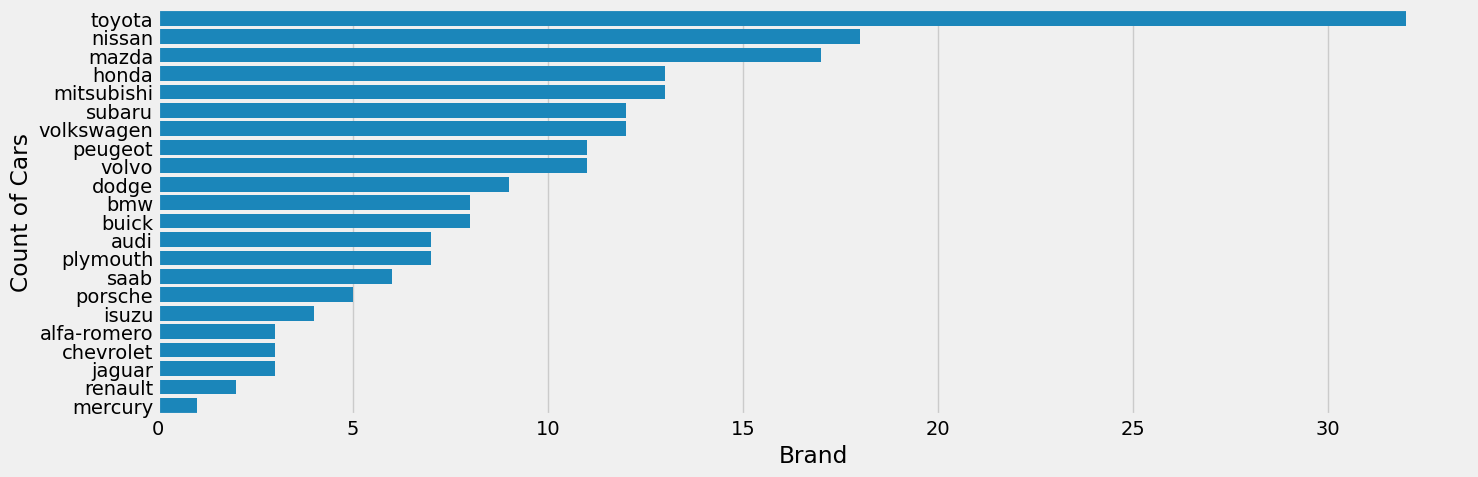

In [448]:
fig, ax = plt.subplots(figsize = (15,5))
plt1 = sns.countplot(data['brand'], order=data.value_counts(data['brand']).index,)
plt1.set(xlabel = 'Brand', ylabel= 'Count of Cars')
plt.tight_layout()
plt.show()

We can drop 'car_ID', 'symboling', and 'CarName' from our data frame, since they will no longer be needed.


In [449]:
data.drop(['car_ID', 'symboling', 'CarName'],axis = 1, inplace = True)

In [450]:
#If you need to save this partially processed data, uncomment the line below.
#data.to_csv('cleaned_car_data.csv', index=False)

**Data Engineer**

Next, we need to engineer some features, for better visualizations and analysis. We will group our data by 'brand', calculate the average price for each brand, and split these prices into 3 bins: 'Budget', 'Mid-Range', and 'Luxury' cars, naming the newly created column - the 'brand_category'. 


In [451]:
data_comp_avg_price = (data[['brand','price']]
 .groupby('brand', as_index=False)
 .mean()
 .rename(columns={'price':'brand_avg_price'}))

data_comp_avg_price.sample(5)


,brand,brand_avg_price
17,saab,15223.333333
16,renault,9595.000000
15,porsche,31400.500000
14,plymouth,7963.428571
20,volkswagen,10077.500000


In [452]:
data = data.merge(data_comp_avg_price, on='brand')
data.sample(5)

,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand,brand_avg_price
46,gas,std,two,hatchback,rwd,front,96.0,172.6,65.2,51.4,...,3.43,3.23,9.2,90,5000,24,29,11048.0,isuzu,8916.500000
161,gas,std,four,hatchback,fwd,front,95.7,166.3,64.4,52.8,...,3.19,3.03,9.0,70,4800,28,34,8358.0,toyota,9885.812500
125,gas,std,two,hatchback,rwd,front,94.5,168.9,68.3,50.2,...,3.94,3.11,9.5,143,5500,19,27,22018.0,porsche,31400.500000
88,gas,std,four,sedan,fwd,front,96.3,172.4,65.4,51.6,...,3.17,3.46,7.5,116,5500,23,30,9279.0,mitsubishi,9239.769231
113,gas,std,four,wagon,rwd,front,114.2,198.9,68.4,56.7,...,3.46,2.19,8.4,95,5000,19,24,16695.0,peugeot,15489.090909


We will now check the statistics of our average car price per car brand.


In [453]:
data.brand_avg_price.describe()

count      205.000000
mean     13276.710571
std       7154.179185
min       6007.000000
25%       9239.769231
50%      10077.500000
75%      15489.090909
max      34600.000000
Name: brand_avg_price, dtype: float64

In [454]:
data['brand_category'] = data['brand_avg_price'].apply(lambda x : "Budget" if x < 10000 
                                                     else ("Mid_Range" if 10000 <= x < 20000
                                                           else "Luxury"))
data.sample(5)

,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,...,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand,brand_avg_price,brand_category
157,gas,std,four,hatchback,fwd,front,95.7,166.3,64.4,52.8,...,3.03,9.0,70,4800,30,37,7198.0,toyota,9885.812500,Budget
31,gas,std,two,hatchback,fwd,front,86.6,144.6,63.9,50.8,...,3.41,9.2,76,6000,31,38,6855.0,honda,8184.692308,Budget
62,gas,std,four,sedan,fwd,front,98.8,177.8,66.5,55.5,...,3.39,8.6,84,4800,26,32,10245.0,mazda,10652.882353,Mid_Range
16,gas,std,two,sedan,rwd,front,103.5,193.8,67.9,53.7,...,3.39,8.0,182,5400,16,22,41315.0,bmw,26118.750000,Luxury
26,gas,std,four,sedan,fwd,front,93.7,157.3,63.8,50.6,...,3.23,9.4,68,5500,31,38,7609.0,dodge,7875.444444,Budget


## 3.**Exploratory Data Analysis**

List of Categorical Variables:
- brand_category
- fueltype
- enginetype
- carbody
- doornumber
- enginelocation
- fuelsystem
- cylindernumber
- aspiration
- drivewheel

We will use the `boxplot()` function on the above mentioned categorical variables, to display the mean, variance, and possible outliers, with respect to the price.

In [455]:
categorical = data.select_dtypes(include='object').columns.tolist()
categorical

['fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'enginetype',
 'cylindernumber',
 'fuelsystem',
 'brand',
 'brand_category']

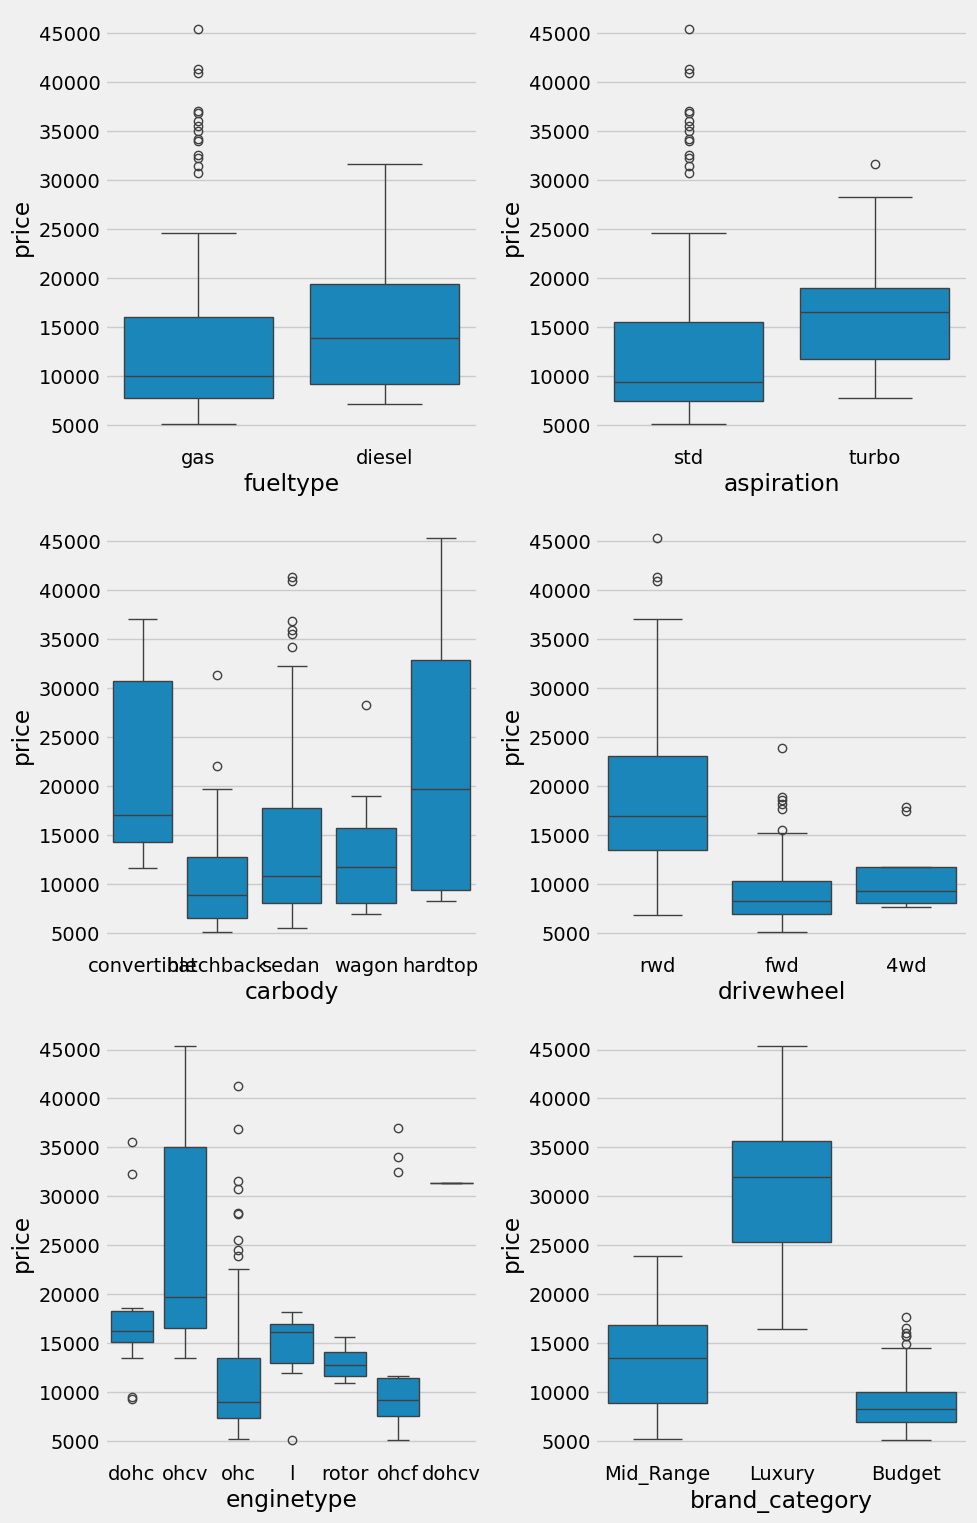

In [456]:
plt.figure(figsize=(10, 20))
plt.subplot(4,2,1)
sns.boxplot(x = 'fueltype', y = 'price', data = data)
plt.subplot(4,2,2)
sns.boxplot(x = 'aspiration', y = 'price', data = data)
plt.subplot(4,2,3)
sns.boxplot(x = 'carbody', y = 'price', data = data)
plt.subplot(4,2,4)
sns.boxplot(x = 'drivewheel', y = 'price', data = data)
plt.subplot(4,2,5)
sns.boxplot(x = 'enginetype', y = 'price', data = data)
plt.subplot(4,2,6)
sns.boxplot(x = 'brand_category', y = 'price', data = data)
plt.tight_layout()
plt.show()

Next, let's view the list of top features that have high correlation coefficient. The `corr()` function calculates the Pearson'r correlation coefficients with respect to the 'price'.


In [457]:
corr_matrix = data.corr(numeric_only=True)

corr_matrix['price'].sort_values(ascending=False)

price               1.000000
brand_avg_price     0.895520
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64

These are strongly correlated numerical features with Car Price.


We can also use the `heatmap()` or `pairplot()` to further explore the relationship between all features and the target variables.

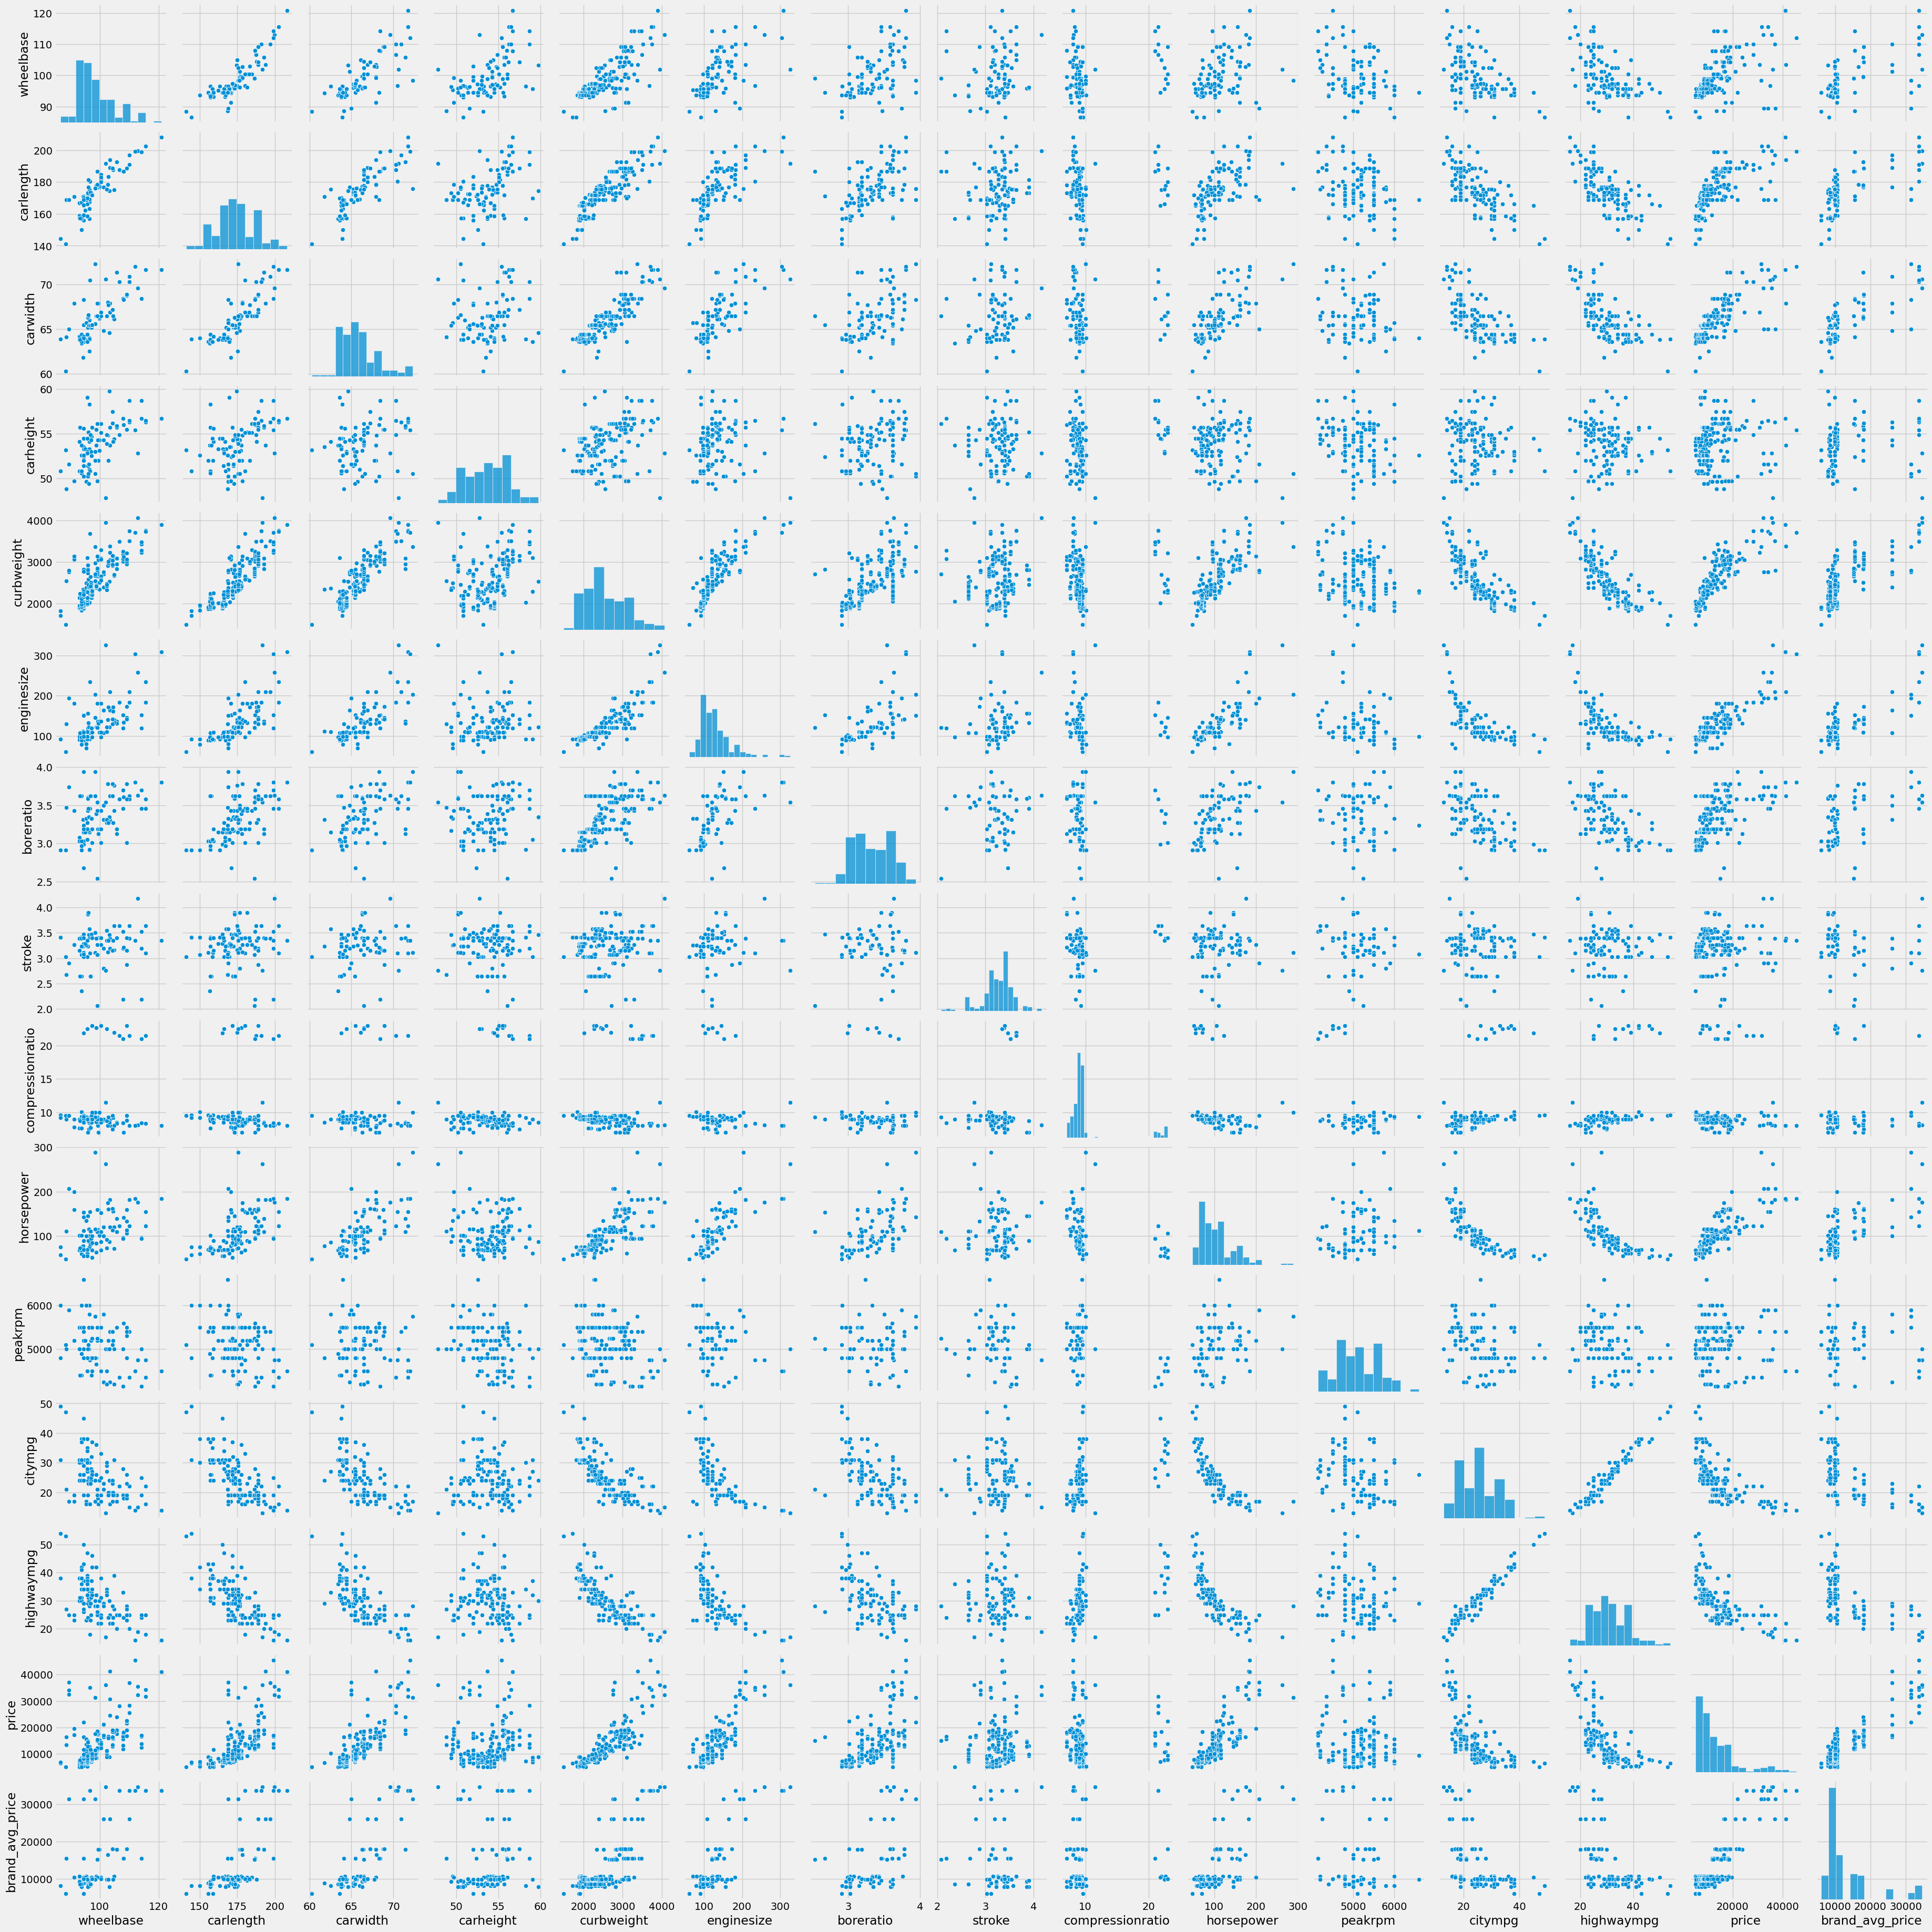

In [458]:
# Enter your code and run the cell
sns.pairplot(data)
plt.show()

## 4. **Testing Assumptions for Linear Regression**

### 1. Linearity Assumption

Linear regression needs the relationship between independent variable and the dependent variable to be linear. We can test this assumption with some scatter plots and regression lines. 

We will start with the 'enginesize' and 'horsepower' features.

- <span style="background-color: green;"> Variable independiente y dependiente sean **Lineal** </span>
- Se puede usar un `scatter` 

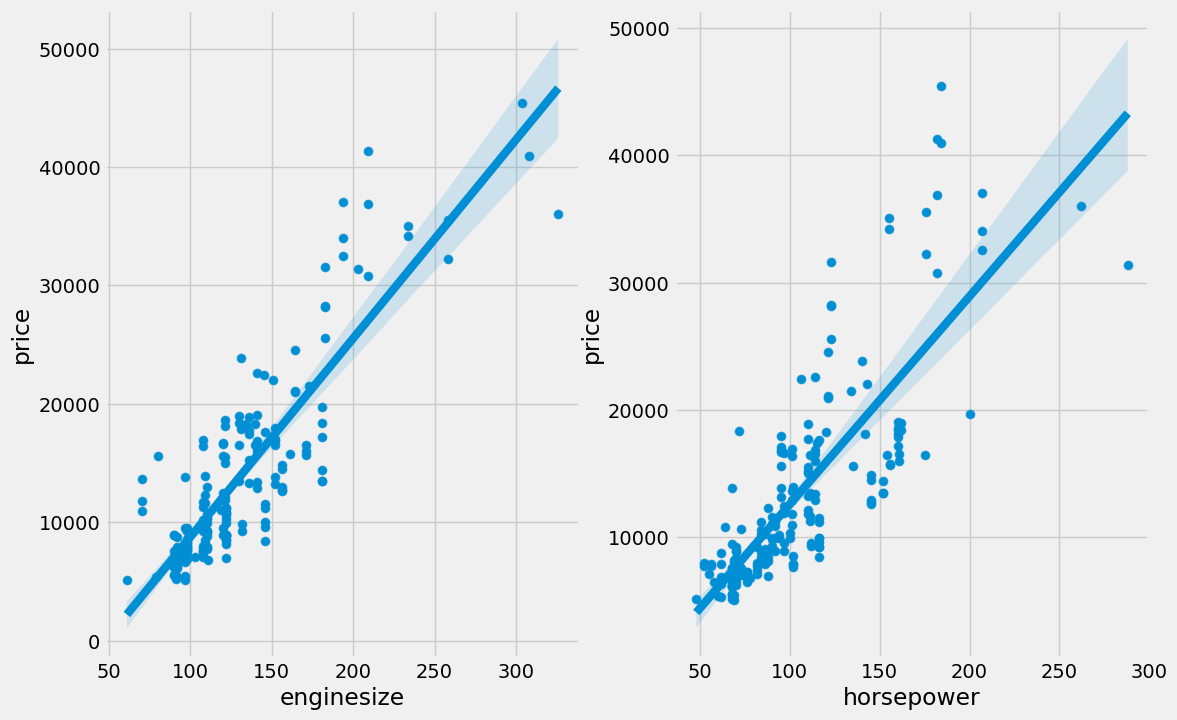

In [459]:

fig, (ax1, ax2) = plt.subplots(figsize = (12,8), ncols=2,sharey=False)
sns.scatterplot( x = data.enginesize, y = data.price,  ax=ax1)
sns.regplot(x=data.enginesize, y=data.price, ax=ax1)
 
sns.scatterplot(x = data.horsepower,y = data.price, ax=ax2)
sns.regplot(x=data.horsepower, y=data.price, ax=ax2);
plt.show()

### 2. *Homoscedasticity*

- <span style="background-color: green;"> Error o ruido se mantenga constante en la Regresion lineal en variables independientes </span>
- <span style="background-color: green;">Si no se mantiene constante se llama Heteroscedesticidad</span>

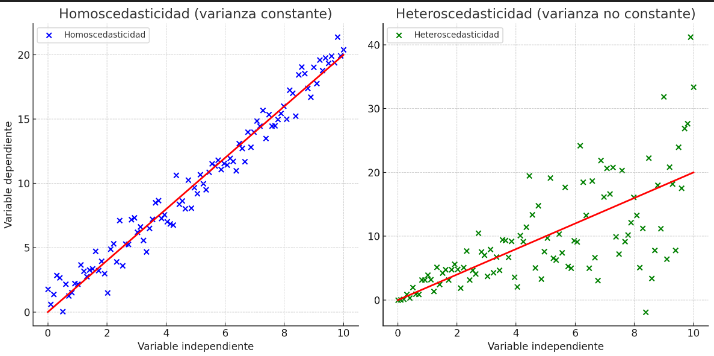

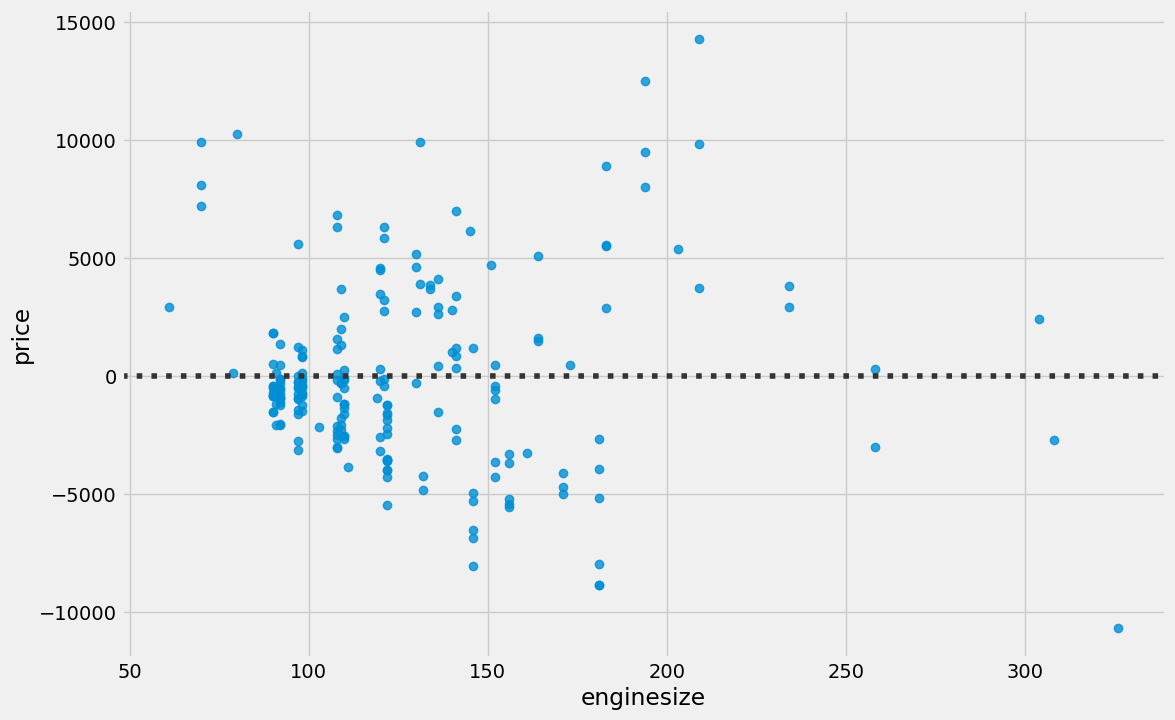

In [460]:
plt.subplots(figsize = (12,8))

#sns.residplot(data.enginesize, data.price)
sns.residplot(data=data, x='enginesize', y='price')
plt.show()

From the above plot, we can tell the error variance across the true line is dispersed somewhat not uniformly, but in a funnel like shape. So, the assumption of the *homoscedasticity* is more likely not met.

### 3. Normality
- La regresión Linea requiere que la variable dependiente (y) tenga una distribución normal.
- p-value > 0.05
- Algunos métodos: `log transformation, square root transformation, box cox transformation`

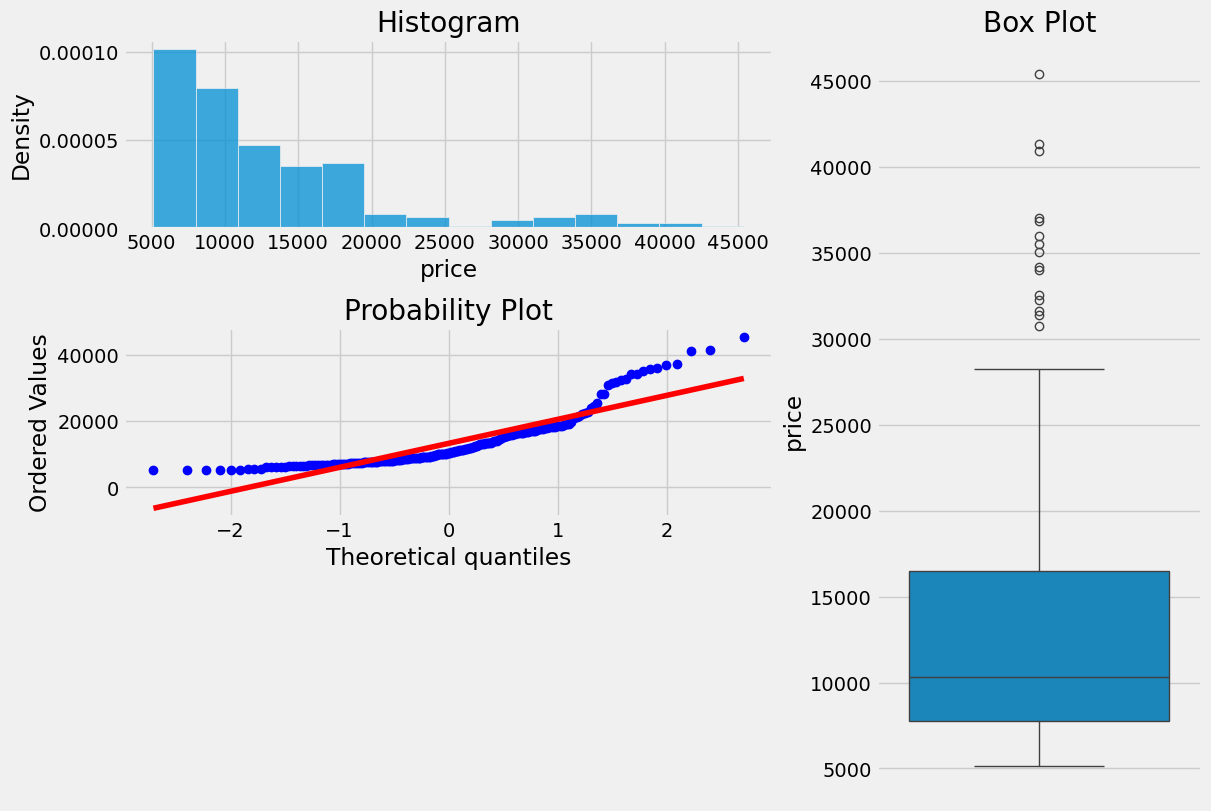

In [461]:
def plotting_3_chart(data, feature):
    ## Importing seaborn, matplotlab and scipy modules. 
    import seaborn as sns
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from scipy import stats
    import matplotlib.style as style
    style.use('fivethirtyeight')

    ## Creating a customized chart. and giving in figsize and everything. 
    fig = plt.figure(constrained_layout=True, figsize=(12,8))
    ## creating a grid of 3 cols and 3 rows. 
    grid = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
    #gs = fig3.add_gridspec(3, 3)

    ## Customizing the histogram grid. 
    ax1 = fig.add_subplot(grid[0, :2])
    ## Set the title. 
    ax1.set_title('Histogram')
    ## plot the histogram. 
    #sns.histplot(data.loc[:,feature], norm_hist=True, ax = ax1)
    sns.histplot(data.loc[:, feature], stat='density', ax=ax1)

    # customizing the QQ_plot. 
    ax2 = fig.add_subplot(grid[1, :2])
    ## Set the title. 
    ax2.set_title('QQ_plot')
    ## Plotting the QQ_Plot. 
    stats.probplot(data.loc[:,feature], plot = ax2)

    ## Customizing the Box Plot. 
    ax3 = fig.add_subplot(grid[:, 2])
    ## Set title. 
    ax3.set_title('Box Plot')
    ## Plotting the box plot. 
    sns.boxplot(y=data.loc[:,feature], orient='v', ax = ax3);

    plt.show()
    
plotting_3_chart(data, 'price')

These three charts above can tell us a lot about our target variable:

- Our target variable, 'price' is not normally distributed
- Our target variable is right-skewed
- There are some outliers in the variable

The right-skewed plot means that most prices in the dataset are on the lower end (below 15,000). The 'max' value is very far from the '75%' quantile statistic. All these plots show that the assumption for accurate linear regression modeling is not met. 

Next, we will perform the log transformation to correct our target variable and to make it more normally distributed. 

But first, we will save our data that we have changed so far, in the 'previous_data' frame.

In [462]:
previous_data = data.copy()

### Log Transformation

We can also check statistically if the target is normally distributed, using `normaltest()` function. If the p-value is large (>0.05), the target variable is normally distributed.


In [463]:
normaltest(data.price.values)

NormaltestResult(statistic=np.float64(77.37514013383584), pvalue=np.float64(1.578344501676757e-17))

As we can see, the p-value is very small, so it is not normally distributed.

Now, we can try to transform our data, so it looks more normally distributed. We can use the `np.log()` or `np.log1p`functions from the `numpy` library to perform the log transformation. The `np.log1p` works better with smaller numbers and thus provides more accurate results. This [documentation](https://numpy.org/doc/stable/reference/generated/numpy.log.html) contains more information about the numpy log transform.

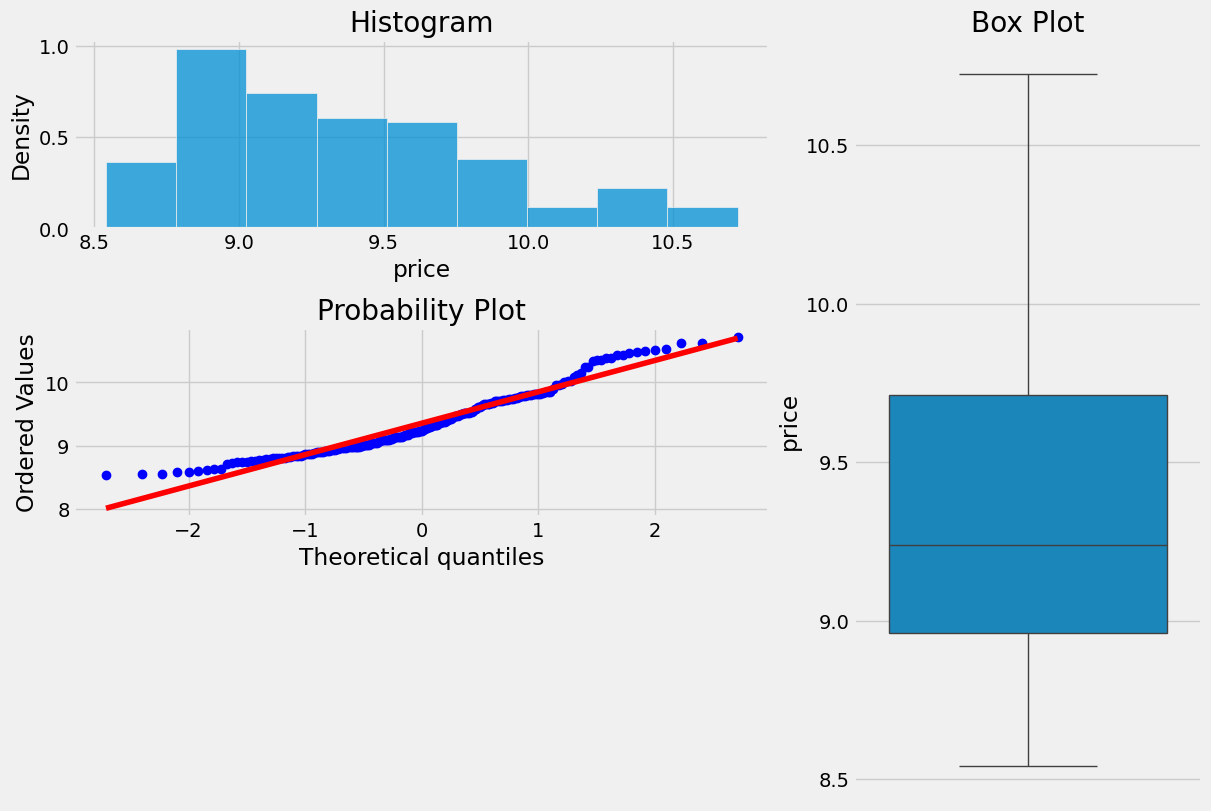

In [464]:

data['price'] = np.log(data['price'])
plotting_3_chart(data, 'price')

Let's check our p-value, after the transformation. 


In [465]:
normaltest(data.price.values)

NormaltestResult(statistic=np.float64(14.10341345775947), pvalue=np.float64(0.0008659297880185564))

As we can see, the log method transformed the car 'price' distribution into a more symmetrical bell curve. It is still not perfect, but it is much closer to being normally distributed.

There are other ways to correct the skewed data. For example, Square Root Transform (`np.sqrt`) and the Box-Cox Transform (`stats.boxcox` from the `scipy stats` library). To learn more about these two methods, please check out this [article](https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45).


### 4. *Multicollinearity*
- Existe cuando hay una fuerte correlación entre variables independientes.
- Usando `heatmap()` se puede detectar la multicolinealidad.
- La mejor forma de resolver la multicolinealidad es usando la **Regularización** con sus métodos como: **Ridge** y **Lasso**

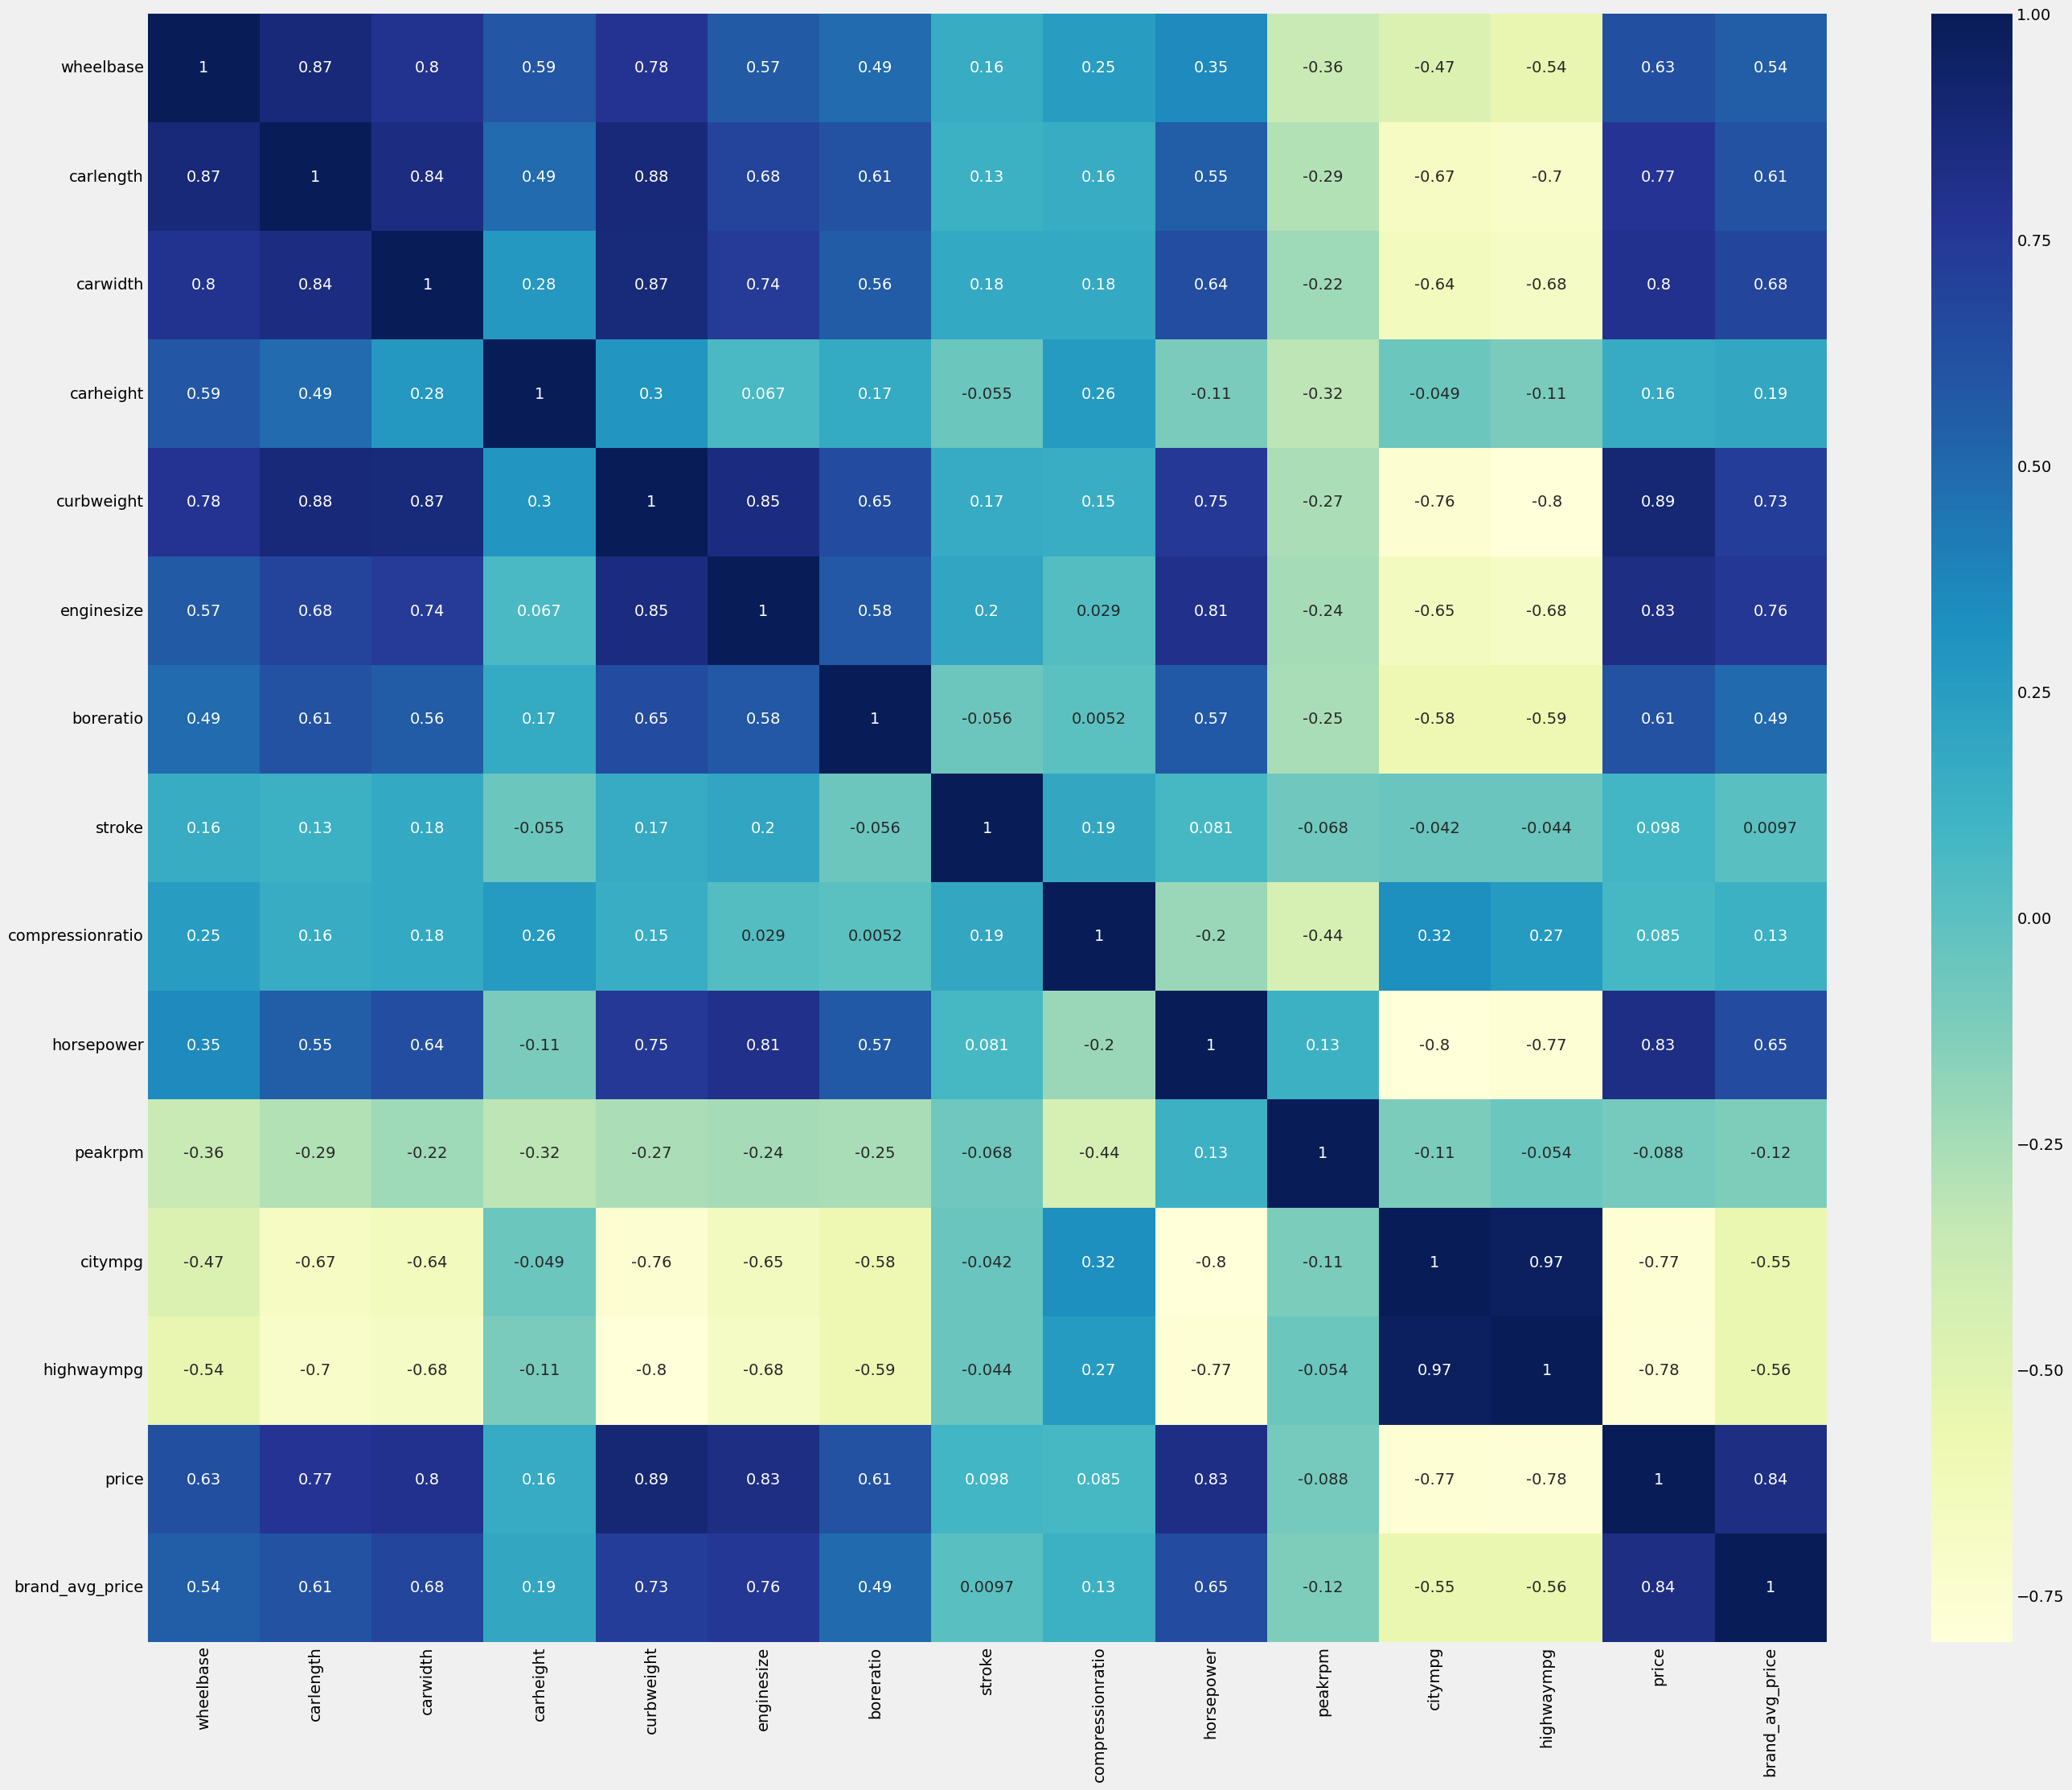

In [466]:
# Enter your code and run the cell
num = data.select_dtypes(include = ['int64', 'float64'])
plt.figure(figsize = (30, 25))
sns.heatmap(num.corr(), annot = True, cmap="YlGnBu")
plt.show()   

As we can see, the multicollinearity still exists in various features. However, we will keep them for now for the sake of learning and let the models (e.x. Regularization models such as Lasso, Ridge in the next lab) do the clean up later on.

## 5. **Linear Regression Model**

List of significant variables after Exploratory Data Analysis :

Numerical:

- Curbweight 
- Car Length
- Car width
- Engine Size 
- Boreratio 
- Horse Power 
- Wheel base 
- City mpg (miles per gallon)
- Highway mpg (miles per gallon)

Categorical:

- Engine Type 
- Fuel type 
- Car Body 
- Aspiration 
- Cylinder Number 
- Drivewheel 
- Brand Category

We are going to put all the selected features into a data frame.


In [467]:
columns=['price', 'fueltype', 'aspiration','carbody', 'drivewheel','wheelbase', 'brand_category',
                  'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'boreratio','horsepower', 'carlength','carwidth','citympg','highwaympg']



selected = data[columns]
selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           205 non-null    float64
 1   fueltype        205 non-null    str    
 2   aspiration      205 non-null    str    
 3   carbody         205 non-null    str    
 4   drivewheel      205 non-null    str    
 5   wheelbase       205 non-null    float64
 6   brand_category  205 non-null    str    
 7   curbweight      205 non-null    int64  
 8   enginetype      205 non-null    str    
 9   cylindernumber  205 non-null    str    
 10  enginesize      205 non-null    int64  
 11  boreratio       205 non-null    float64
 12  horsepower      205 non-null    int64  
 13  carlength       205 non-null    float64
 14  carwidth        205 non-null    float64
 15  citympg         205 non-null    int64  
 16  highwaympg      205 non-null    int64  
dtypes: float64(5), int64(5), str(7)
memory usage: 

We can find the categorical and numeric columns by  iterating  through the ```dtypes```  attribute.


In [468]:
categorical_columns = selected.select_dtypes(include='object').columns.tolist()
categorical_columns

['fueltype',
 'aspiration',
 'carbody',
 'drivewheel',
 'brand_category',
 'enginetype',
 'cylindernumber']

In [469]:
numerical_columns = selected.select_dtypes(include='number').columns.tolist()
numerical_columns

['price',
 'wheelbase',
 'curbweight',
 'enginesize',
 'boreratio',
 'horsepower',
 'carlength',
 'carwidth',
 'citympg',
 'highwaympg']

We can split the data into the features ```X``` and target ```y```.


In [470]:
X = selected.drop("price", axis=1)
y = selected["price"].copy()

Before we used one-hot encoding to deal with the categorical data, let's examine the distribution of the categorical variables:

In [471]:
for column in  categorical_columns:
    print("column name:", column)
    print("value_count:")
    print( X[column].value_counts())

column name: fueltype
value_count:
fueltype
gas       185
diesel     20
Name: count, dtype: int64
column name: aspiration
value_count:
aspiration
std      168
turbo     37
Name: count, dtype: int64
column name: carbody
value_count:
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
column name: drivewheel
value_count:
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
column name: brand_category
value_count:
brand_category
Budget       95
Mid_Range    86
Luxury       24
Name: count, dtype: int64
column name: enginetype
value_count:
enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64
column name: cylindernumber
value_count:
cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64


- Observamos que muchas categoricas tiene pocas o muy pocas ocurrencias, por ejemplo `three`, `twelve` que solo ocurre una ves en la columna `cylindernumber`. 
- Si usamos one-hot encoder usando training data, los ejemplares de la columna `cylindernumber` no incluirá three o twelve obtengamos un error.
- Por lo tanto, debemos usar split antes de transformar con one-hot.
- Es importante analizar la distribuciones antes de aplicar one-hot, algunas veces se tendrá que hacer antes del split, y otras después del split. 

## 6. OneHotEncoder


We will use the following modules:


In [472]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

To perform one-hot encoding, we use the ```ColumnTransformer``` class, this allows different columns or column subsets to be transformed separately. 

The input is as follows:

The `transformerslist` is the number of tuples.
The list of `(name, transformer, columns)` tuples specify the transformer objects to be applied to the subsets of the data.

*   name: name of the operation that can be used later 
*  `transformer`: estimator must support fit and transform, in this case we will use `OneHotEncoder()`
*  `‘drop’`: to  drop the columns 
*  `‘passthrough’`: to pass them through untransformed data
*  `remainder`: specifies the columns that are not transformed are being set to `passthrough`. They are  combined in the output, and the non-specified columns are dropped.


We apply ```fit_transform()``` to transform the data.

In [473]:
one_hot = ColumnTransformer(transformers=[("one_hot", OneHotEncoder(), categorical_columns)],
                  remainder="passthrough")

X = one_hot.fit_transform(X)
type(X)

numpy.ndarray

We see the output is a NumPy array, so let's get the feature names from the ```one_hot``` object using  ```get_feature_names_out()``` method. The output  will be the feature name with the  prefix of the name of the transformer. For one-hot encoding, the prefix will also include the name of the column that generated that feature. 


In [474]:
names = one_hot.get_feature_names_out()
names

array(['one_hot__fueltype_diesel', 'one_hot__fueltype_gas',
       'one_hot__aspiration_std', 'one_hot__aspiration_turbo',
       'one_hot__carbody_convertible', 'one_hot__carbody_hardtop',
       'one_hot__carbody_hatchback', 'one_hot__carbody_sedan',
       'one_hot__carbody_wagon', 'one_hot__drivewheel_4wd',
       'one_hot__drivewheel_fwd', 'one_hot__drivewheel_rwd',
       'one_hot__brand_category_Budget', 'one_hot__brand_category_Luxury',
       'one_hot__brand_category_Mid_Range', 'one_hot__enginetype_dohc',
       'one_hot__enginetype_dohcv', 'one_hot__enginetype_l',
       'one_hot__enginetype_ohc', 'one_hot__enginetype_ohcf',
       'one_hot__enginetype_ohcv', 'one_hot__enginetype_rotor',
       'one_hot__cylindernumber_eight', 'one_hot__cylindernumber_five',
       'one_hot__cylindernumber_four', 'one_hot__cylindernumber_six',
       'one_hot__cylindernumber_three', 'one_hot__cylindernumber_twelve',
       'one_hot__cylindernumber_two', 'remainder__wheelbase',
       'remain

Let's strip out the prefix of the string. 


In [475]:
colunm_names=[name[name.find("_")+1:] for name in  
              [name[name.find("__")+2:] for name in names]]
colunm_names

['diesel',
 'gas',
 'std',
 'turbo',
 'convertible',
 'hardtop',
 'hatchback',
 'sedan',
 'wagon',
 '4wd',
 'fwd',
 'rwd',
 'category_Budget',
 'category_Luxury',
 'category_Mid_Range',
 'dohc',
 'dohcv',
 'l',
 'ohc',
 'ohcf',
 'ohcv',
 'rotor',
 'eight',
 'five',
 'four',
 'six',
 'three',
 'twelve',
 'two',
 'wheelbase',
 'curbweight',
 'enginesize',
 'boreratio',
 'horsepower',
 'carlength',
 'carwidth',
 'citympg',
 'highwaympg']

We can save the result as a dataframe to be used in other labs. 


In [476]:
df=pd.DataFrame(data=X,columns=colunm_names)

#df.to_csv('cleaned_car_data.csv', index=False)

### 7. Train Test Split

In the following Module 2: Data Splits and Cross Validation section of the Course, we will learn more about train and test split of the data deeper. But for now, we use `train_test_split()` function from *sklearn.model_selection* library to split our data into training and testing sets, using 30% of the data for testing.

In [477]:
from sklearn.model_selection import train_test_split

In [478]:
X_train, X_test, y_train, y_test = train_test_split( df, y, test_size=0.30, random_state=0)

### 8. Standardize the Data

We standardize features by removing the mean and scaling to unit variance using ```StandardScaler```, we create a 
```StandardScaler``` object:

In [479]:
from sklearn.preprocessing import StandardScaler

We `fit` our training data, then we `transform` it.


In [480]:
ss = StandardScaler()

X_train = ss.fit_transform(X_train)

### 9. Linear Regression

Finally, we apply the `LinearRegression()` model and `fit()` our ```X``` and ```y``` data.


In [481]:
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 10. Making Prediction

We will select some random data and apply the `predict()` function.


In [482]:
X_test = ss.transform(X_test)
car_price_predictions = lm.predict(X_test)
car_price_predictions

array([ 8.87368304,  9.76331696,  9.37619842,  8.20809049,  9.25745786,
        9.34999919,  8.689579  ,  8.80059779,  9.65140161,  8.81774326,
        9.8938222 , 11.24667301,  9.44950493,  9.481259  ,  8.72871162,
        9.27212737,  9.08262263,  9.59959188,  9.00069293,  8.7891817 ,
        9.23208309,  9.57673884,  9.1051809 ,  9.32525256,  9.77744006,
        8.84073863,  8.88827629,  9.61747728,  8.88440132,  8.87820614,
        9.14354562,  9.25682971,  9.95926555,  9.11083654,  8.8941763 ,
       10.41503322,  9.46099431,  9.69174397,  8.76421616, 10.39857862,
        8.71730437,  9.46022563, 10.49092027,  9.43574582,  9.28851633,
        8.85645216,  8.83208564,  9.46205321,  9.21390927,  9.16505643,
        9.87649543,  8.85499701,  8.94926626,  9.1589375 ,  9.96129128,
        9.75392034,  9.19284805, 10.00570084,  9.19349866,  8.79387501,
        8.36298001,  9.52011437])

### 11. Model Evaluation 
- `mean_squared_error()` evalua que tan lejos está de los valores predichos con los reales, entre más cercano a 0 mejor.


- For more information on MSE, please visit this wikipedia [site](https://en.wikipedia.org/wiki/Mean_squared_error).


In [483]:
mse = mean_squared_error(y_test, car_price_predictions)
mse

0.041043876224838814

- `R-squered` es coeficiente de determinación, entre más cercano a 1 mejor. 

In [484]:
lm.score(X_test,y_test)
# lm.score(X_train, y_train)

0.8405015757109263

- `R2_score` retorna la misma estadistica que `R-squared`

In [485]:
from sklearn.metrics import r2_score 

In [486]:
r2_score(y_test,car_price_predictions)

0.8405015757109263

**Importante**
Si `R-squared` es negativo, significa overfitting, cuando un modelo estadistico ajusta exactamente lo contrario a su training data.

### 12. Pipeline Object

We can also create a Pipeline object and apply a set of transforms sequentially. Then, we can apply linear regression.  Data Pipelines simplify the steps of processing the data. We use the module Pipeline to create a pipeline. We also use ```StandardScaler```as a step in our pipeline.

 We create the pipeline, by creating a list of tuples including the name of the model or estimator and its corresponding constructor.

In [487]:
steps = [('scaler', StandardScaler()),
         ('lm', LinearRegression())]

 We input the list as an argument to the pipeline constructor.


In [488]:
pipe = Pipeline(steps=steps)

 We ```fit``` the constructor.


In [489]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


We make a prediction and perform model evaluation.


In [490]:
car_price_predictions = pipe.predict(X_test)

mse = mean_squared_error(y_test, car_price_predictions)

print(f"mse: {mse}")

rmse = np.sqrt(mse)

print(f"rmse: {rmse}")

r2score = r2_score(car_price_predictions, y_test)

print(f"r2_score {r2score}")

mse: 0.04104387622483889
rmse: 0.20259288295702516
r2_score 0.8556781711087368


Use the  ``ColumnTransformer`` in the pipeline, then train the model using <b>all</b> the data, make a prediction and calculate all the  metrics.

In [491]:

X = selected[categorical_columns + numerical_columns].drop(columns=['brand_category'])
y = data['price']


In [492]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [493]:
categorical_columns.remove('brand_category')


In [494]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ]
)

In [495]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])


In [496]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [497]:
y_pred = pipe.predict(X_test)

In [498]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 1.0
MAE: 1.5597279565465614e-15
RMSE: 1.7978892236224693e-15
